# Apply Decision Tree and Random Forest for classification tasks

## 1. Import Required Libraries
Import necessary libraries such as pandas, numpy, and scikit-learn modules for models and evaluation metrics.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load and Prepare Data
Load the dataset `WA_Fn-UseC_-Telco-Customer-Churn.xls`, handle any preprocessing, and perform a train-test split.

In [5]:
# Load the dataset
# Note: Ensure you have xlrd openpyxl installed to read .xls files. 
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.xls')

# Basic Preprocessing
# Replace empty strings with NaN and drop missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan))
df.dropna(inplace=True)

# Drop customerID as it is not needed for prediction
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Encode categorical variables
le = LabelEncoder()
for col in df.select_dtypes(exclude=['number']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Features and Target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


## 3. Implement Decision Tree Classifier
Initialize and train a DecisionTreeClassifier on the training data, then generate predictions on the test set.

In [6]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

dt_predictions = dt_classifier.predict(X_test)

## 4. Evaluate Decision Tree Model
Calculate and display evaluation metrics including accuracy score, confusion matrix, and classification report for the Decision Tree.

Decision Tree Accuracy: 0.7249466950959488

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81      1033
           1       0.48      0.52      0.50       374

    accuracy                           0.72      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.72      0.73      1407



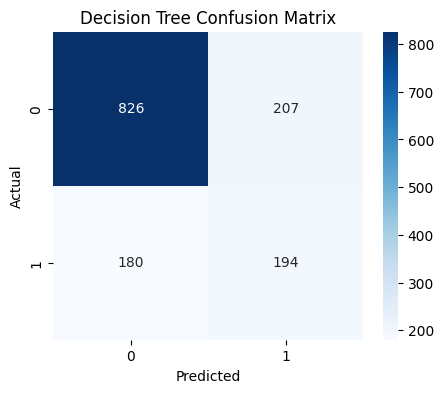

In [7]:
dt_accuracy = accuracy_score(y_test, dt_predictions)
print("Decision Tree Accuracy:", dt_accuracy)
print("\nClassification Report:\n", classification_report(y_test, dt_predictions))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, dt_predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 5. Implement Random Forest Classifier
Initialize and train a RandomForestClassifier on the training data, then generate predictions on the test set.

In [8]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

rf_predictions = rf_classifier.predict(X_test)

## 6. Evaluate Random Forest Model
Calculate and display evaluation metrics including accuracy score, confusion matrix, and classification report for the Random Forest.

Random Forest Accuracy: 0.7924662402274343

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



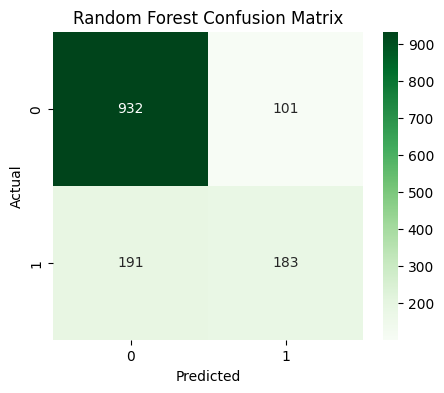

In [9]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest Accuracy:", rf_accuracy)
print("\nClassification Report:\n", classification_report(y_test, rf_predictions))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, rf_predictions), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 7. Compare Models
Visualize and compare the performance metrics of both the Decision Tree and Random Forest classifiers.

C:\Users\SAMEEKSHA\AppData\Local\Temp\ipykernel_33120\3551072743.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette=['skyblue', 'lightgreen'])


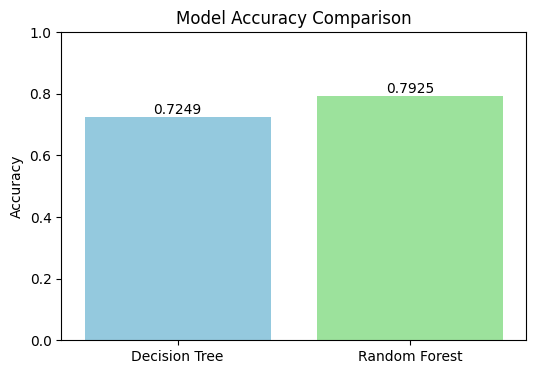

In [10]:
models = ['Decision Tree', 'Random Forest']
accuracies = [dt_accuracy, rf_accuracy]

plt.figure(figsize=(6,4))
sns.barplot(x=models, y=accuracies, palette=['skyblue', 'lightgreen'])
plt.ylim(0, 1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()